In [ ]:
from utils import *
from nilearn import datasets, image
from nilearn import image as nimg
from scipy.stats import chi2, norm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import pdist, squareform
from itertools import cycle, islice

#------------------------------- add variables

qc_df = pd.read_excel(f'{data_dir}/quality-control/QC_n97.xlsx')
data = data.merge(qc_df[['sub_id', 'fd_mean']], on='sub_id', how='left')

# use measure
data['frac_yrs_using'] = data['coc_dur_years'] / data['age_years']

# new dots measures
data['beh_dots_dist_zscore'] = (
    data['beh_dots_dist_mean'] - data['beh_dots_dist_shuff_mean']
) / data['beh_dots_dist_shuff_std']
def compute_subject_placement_rsa(coords_task, coords_dots):
    """
    coords_task: (N, C, 2) task-derived coordinates
    coords_dots: (N, C, 2) subjective placement coordinates

    Returns:
      tau: (N,) Kendall's tau per subject
    """
    N = coords_task.shape[0]
    taus = np.full(N, np.nan)

    for i in range(N):
        X = coords_task[i]  # (C, 2)
        Y = coords_dots[i]  # (C, 2)

        # Check for missing values
        if not np.isfinite(X).all() or not np.isfinite(Y).all():
            continue

        # Distance matrices
        D_task = pdist(X, metric="euclidean")
        D_dots = pdist(Y, metric="euclidean")

        # Rank-based RSA
        tau, _ = kendalltau(D_task, D_dots)
        taus[i] = tau

    return taus

coords_beh  = get_coords(data, which='task', include_neutral=True)
coords_dots = get_coords(data, which='dots', include_neutral=True)
data["placement_tau"] = compute_subject_placement_rsa(coords_beh, coords_dots)

from scipy.spatial.distance import cdist
def neighbor_preservation(coords_task, coords_dots, *, k=1, return_per_char=False):
    """
    Neighbor preservation between task coords and dot coords.

    Parameters
    ----------
    coords_task : array, shape (N, C, 2)
        Task-derived character coordinates per subject.
    coords_dots : array, shape (N, C, 2)
        Dot-placement coordinates per subject.
    k : int
        Number of nearest neighbors to compare (k=1 is simplest).
    return_per_char : bool
        If True, also return per-character accuracies (N, C).

    Returns
    -------
    score : array, shape (N,)
        Mean fraction of preserved neighbors across characters for each subject.
    per_char : array, shape (N, C), optional
        Per-character fraction preserved (averaged over k neighbors).
    """
    coords_task = np.asarray(coords_task, float)
    coords_dots = np.asarray(coords_dots, float)

    N, C, _ = coords_task.shape
    scores = np.full(N, np.nan)
    per_char = np.full((N, C), np.nan)

    for i in range(N):
        X = coords_task[i]
        Y = coords_dots[i]

        if not (np.isfinite(X).all() and np.isfinite(Y).all()):
            continue

        D_task = cdist(X, X, metric="euclidean")
        D_dots = cdist(Y, Y, metric="euclidean")

        np.fill_diagonal(D_task, np.inf)
        np.fill_diagonal(D_dots, np.inf)

        hits = []
        for c in range(C):
            nn_task = np.argsort(D_task[c])[:k]
            nn_dots = np.argsort(D_dots[c])[:k]
            # fraction of task neighbors recovered in dots
            hit = np.intersect1d(nn_task, nn_dots).size / float(k)
            hits.append(hit)
            per_char[i, c] = hit

        scores[i] = float(np.mean(hits))

    if return_per_char:
        return scores, per_char
    return scores

data["nn_score_k1"] = neighbor_preservation(coords_beh, coords_dots, k=1)


In [3]:
glm_dir = "../analyses/lsa/glms/"

subject_data = {}
for sub_id in tqdm(incl_subs):
    try:
        subject_data[sub_id] = load_subject_data(
            sub_id=sub_id,
            atlas=atlas_pkl, 
            glm_dir=glm_dir,
            load_sem=True,
            load_fmri=True,
        )
    except Exception as e:
        print(e)


 92%|█████████▏| 73/79 [01:27<00:07,  1.24s/it]

Beta image not found: ../analyses/lsa/glms/sub-23009/beta_decisions.nii.gz
Beta image not found: ../analyses/lsa/glms/sub-23010/beta_decisions.nii.gz


 97%|█████████▋| 77/79 [01:29<00:01,  1.17it/s]

Beta image not found: ../analyses/lsa/glms/sub-23020/beta_decisions.nii.gz


100%|██████████| 79/79 [01:30<00:00,  1.15s/it]


<h1 align='center'> Basic social space RSAs </h1>

In [4]:
def run_location_within_rsa(
    all_data,
    *,
    coord_cols: tuple[str, str] = ("affil_coord", "power_coord"),
    onset_col: str = "onset",
    char_col: str = "character_role_num",
    on_error: str = "skip_subject",   # {"skip_subject","skip_roi","raise"}
    return_failures: bool = False,
):
    """
    WITHIN-character trialwise RSA (ROI-based, like run_simple_location_rsa):

      For each character separately:
        - neural RDV = pdist(betas_char, metric="correlation"), z-scored within character
        - social RDV = pdist(coords_char, metric="euclidean"),   z-scored within character
        - time  RDV  = pdist(onset_char, metric="euclidean"),    z-scored within character

      Concatenate RDVs across characters and run RSA regression:
        neural ~ social + time (nuisance)

    Returns per-subject, per-ROI stats in the same schema as run_simple_location_rsa.
    """

    def _get_roi_code_to_label(sd: dict) -> dict[int, str]:
        if "atlas" in sd and isinstance(sd["atlas"], dict) and "rois" in sd["atlas"]:
            rois = sd["atlas"]["rois"]
            if isinstance(rois, dict):
                try:
                    return {int(k): str(v) for k, v in rois.items()}
                except Exception:
                    pass
        if "roi_labels" in sd and isinstance(sd["roi_labels"], dict):
            rois = sd["roi_labels"]
            try:
                return {int(k): str(v) for k, v in rois.items()}
            except Exception:
                pass
        return {}

    def _normalize_roi_name(roi_key, code_to_label: dict[int, str]) -> str:
        if isinstance(roi_key, str):
            return roi_key
        try:
            k = int(roi_key)
        except Exception:
            return str(roi_key)
        return code_to_label.get(k, str(k))

    def _z(x, eps=1e-12):
        x = np.asarray(x, float)
        m = np.nanmean(x)
        s = np.nanstd(x)
        return (x - m) / (s + eps)

    def _handle(err, *, sub_id, stage, roi=None):
        msg = f"{type(err).__name__}: {err}"
        failures.append({"sub_id": sub_id, "roi": roi, "stage": stage, "error": msg})

        if on_error == "raise":
            raise err
        if on_error == "skip_subject":
            raise _SkipSubject
        return  # skip_roi

    class _SkipSubject(Exception):
        pass

    c1, c2 = coord_cols
    rows = []
    failures = []

    for sub_id, sd in all_data.items():
        if "behavior" not in sd or "roi_betas" not in sd:
            continue

        behav = sd["behavior"]
        rois  = sd["roi_betas"]
        code_to_label = _get_roi_code_to_label(sd)

        try:
            required = [c1, c2, onset_col, char_col]
            missing = [c for c in required if c not in behav.columns]
            if missing:
                raise ValueError(f"missing behavior columns: {missing}")

            coords = behav[[c1, c2]].to_numpy(float)
            onset  = behav[onset_col].to_numpy(float)
            chars  = behav[char_col].to_numpy()

            if coords.ndim != 2 or coords.shape[1] != 2:
                raise ValueError(f"coords has shape {coords.shape}, expected (T,2)")

            if not np.isfinite(coords).all():
                bad = np.where(~np.isfinite(coords).all(axis=1))[0]
                _handle(
                    ValueError(
                        f"non-finite values in coord_cols {coord_cols} at trials {bad[:10].tolist()}"
                    ),
                    sub_id=sub_id,
                    stage="subject_setup",
                )
                continue

            if not np.isfinite(onset).all():
                bad = np.where(~np.isfinite(onset))[0]
                _handle(
                    ValueError(f"non-finite values in onset_col {onset_col} at trials {bad[:10].tolist()}"),
                    sub_id=sub_id,
                    stage="subject_setup",
                )
                continue

            # indices per character (within-character pairs only)
            char_to_idx = {}
            for i, c in enumerate(chars):
                char_to_idx.setdefault(c, []).append(i)

            # keep only characters with >= 3 trials (otherwise pdist gives 0/empty or unstable)
            char_to_idx = {c: np.asarray(ix, int) for c, ix in char_to_idx.items() if len(ix) >= 3}
            if len(char_to_idx) == 0:
                raise ValueError("no characters with >=3 trials (within-character RSA undefined)")

        except _SkipSubject:
            continue
        except Exception as e:
            _handle(e, sub_id=sub_id, stage="subject_setup")
            continue

        for roi_key, betas in rois.items():
            roi_name = _normalize_roi_name(roi_key, code_to_label)
            try:
                betas = np.asarray(betas)

                if betas.ndim != 2:
                    raise ValueError(f"betas has shape {betas.shape}, expected (T,V)")

                if betas.shape[0] != coords.shape[0]:
                    raise ValueError(
                        f"trial mismatch: betas={betas.shape[0]}, behav={coords.shape[0]}"
                    )

                # build within-character, z-scored blocks and concatenate
                y_blocks = []
                loc_blocks = []
                time_blocks = []

                for c, ix in char_to_idx.items():
                    Bc = betas[ix, :]
                    Xc = coords[ix, :]
                    Tc = onset[ix]

                    # neural RDV
                    y = pdist(Bc, metric="correlation").astype(float)
                    # predictor RDVs
                    d_loc = pdist(Xc, metric="euclidean").astype(float)
                    d_t   = pdist(Tc[:, None], metric="euclidean").astype(float)

                    # z-score within character
                    y_blocks.append(_z(y))
                    loc_blocks.append(_z(d_loc))
                    time_blocks.append(_z(d_t))

                y_all = np.concatenate(y_blocks, axis=0)
                loc_all = np.concatenate(loc_blocks, axis=0)
                time_all = np.concatenate(time_blocks, axis=0)

                stats = fit_rsa_regression(
                    y_all,
                    design_rdvs={"social_loc": loc_all},
                    nuisance_rdvs={"time": time_all},
                )

                rows.append({
                    "sub_id": sub_id,
                    "roi": roi_name,
                    "coord_space": f"{c1},{c2}",
                    "beta": stats["beta_social_loc"],
                    "t_stat": stats["t_social_loc"],
                    "p_val": stats["p_social_loc"],
                    "r2_adj": stats["R2_adj"],
                    "rsa_variant": "within_char_z",
                    "n_chars_used": len(char_to_idx),
                    "n_pairs_used": int(y_all.size),
                })

            except _SkipSubject:
                break
            except Exception as e:
                _handle(e, sub_id=sub_id, stage="roi_fit", roi=roi_name)
                if on_error == "skip_subject":
                    break
                continue

    df = pd.DataFrame(rows)
    if return_failures:
        return df, pd.DataFrame(failures)
    return df

df_within_orig = run_location_within_rsa(
    subject_data,
    coord_cols=("affil_coord", "power_coord"),
    on_error="skip_subject",
)

df_within_dots = run_location_within_rsa(
    subject_data,
    coord_cols=("affil_coord_in_dots", "power_coord_in_dots"),
    on_error="skip_subject",
)

df_rsa = df_within_orig.merge(df_within_dots, on=["sub_id", "roi"], suffixes=("_orig", "_dots"))
df_rsa["beta_delta"] = df_rsa["beta_dots"] - df_rsa["beta_orig"]
df_rsa = df_rsa.merge(data, on='sub_id', how='left')

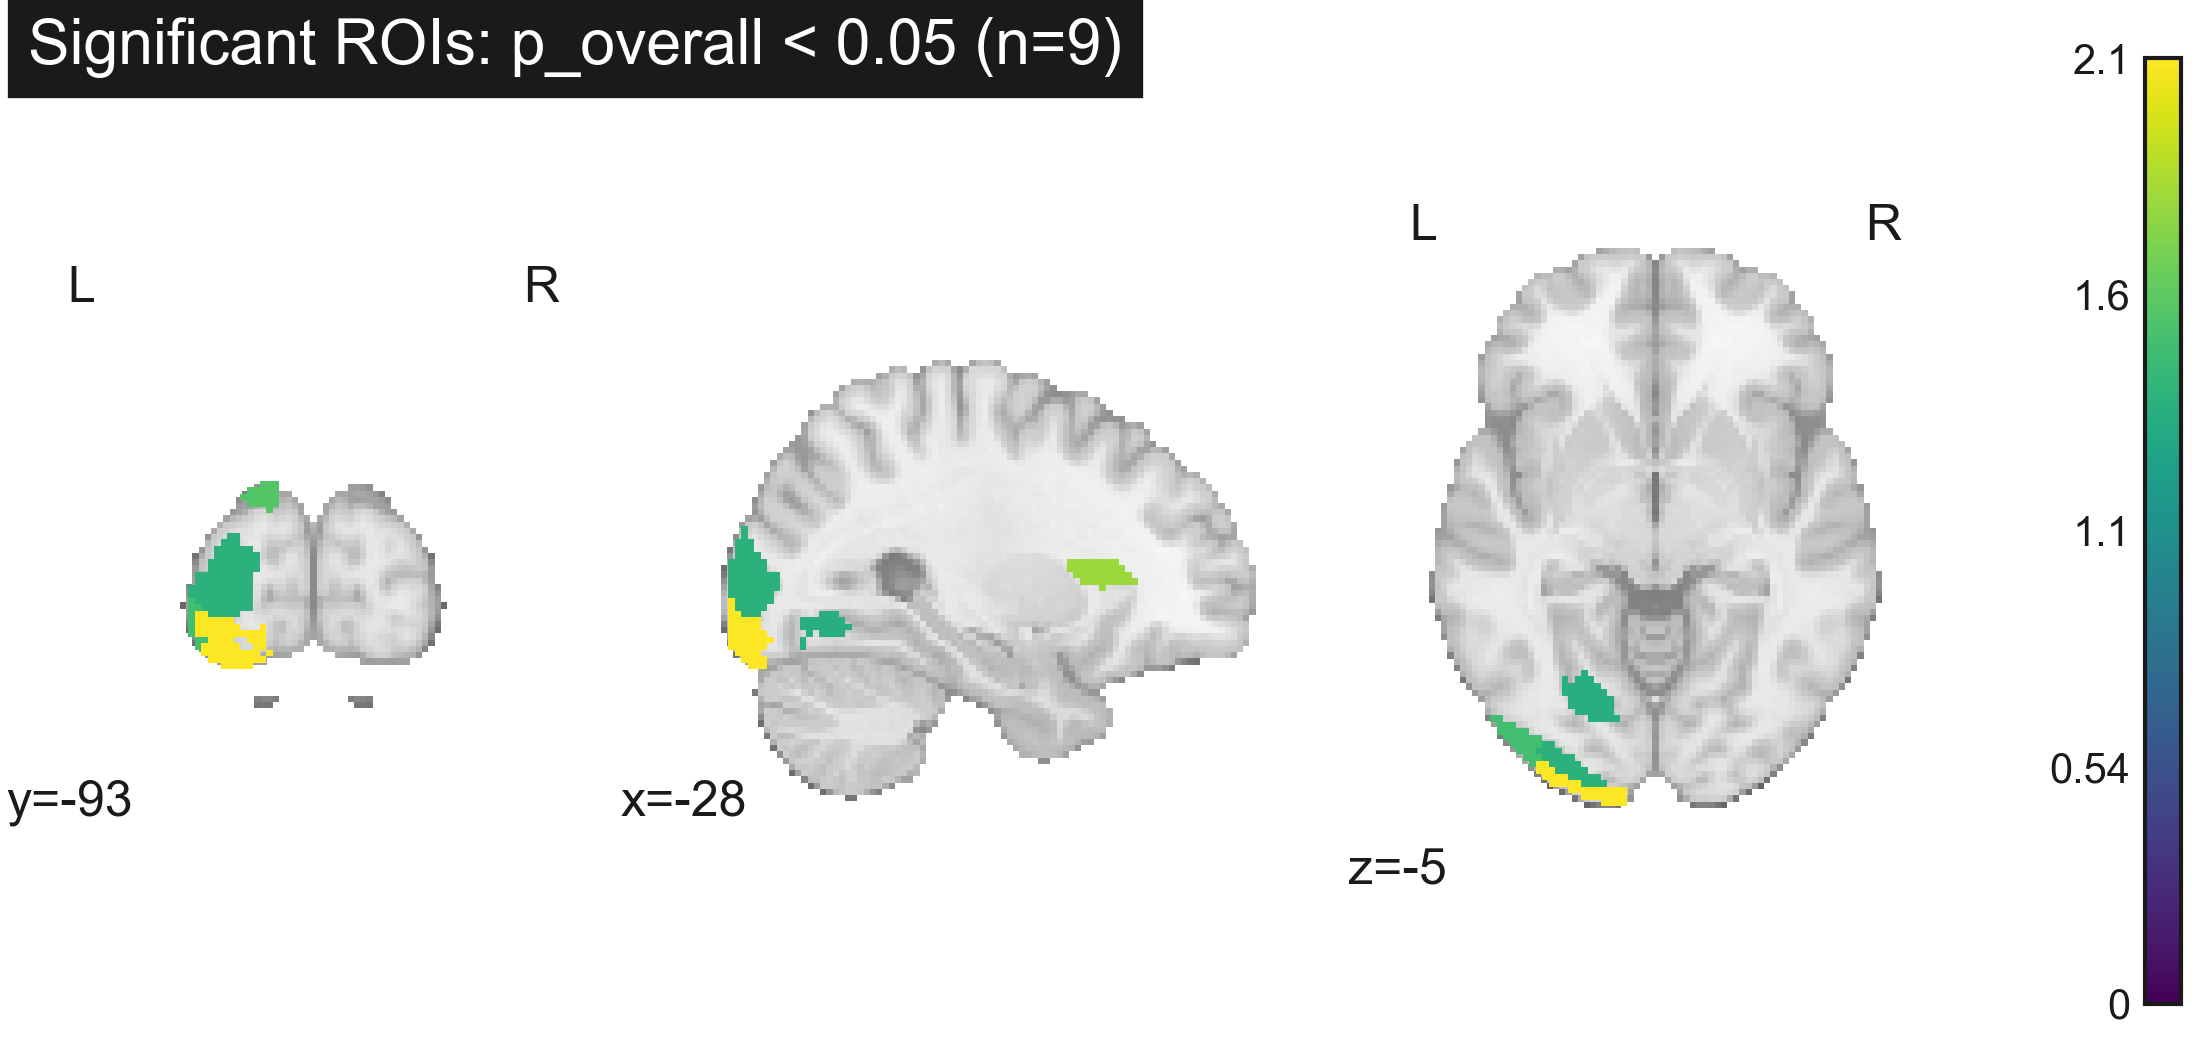

(                                      roi  p_overall
 10                    7Networks_LH_Vis_11   0.007227
 75   7Networks_LH_SalVentAttn_FrOperIns_3   0.015103
 109              7Networks_LH_Cont_Cing_1   0.023092
 22                    7Networks_LH_Vis_23   0.027201
 7                      7Networks_LH_Vis_8   0.032435
 138           7Networks_LH_Default_PFC_15   0.041434
 14                    7Networks_LH_Vis_15   0.041944
 4                      7Networks_LH_Vis_5   0.044622
 72     7Networks_LH_SalVentAttn_TempOcc_1   0.044836,
 <nibabel.nifti1.Nifti1Image at 0x325a10750>)

In [5]:
df_rsa = df_within_dots.merge(data, on='sub_id', how='left')
res_df = roi_group_tests(df_rsa, y_col='beta')
plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_overall')

## location similarity

In [6]:
def run_location_rsa(
    all_data,
    *,
    coord_cols: tuple[str, str] = ("affil_coord", "power_coord"),
    onset_col: str = "onset",
    on_error: str = "skip_subject",   # {"skip_subject","skip_roi","raise"}
    return_failures: bool = False,
):
    def _get_roi_code_to_label(sd: dict) -> dict[int, str]:
        if "atlas" in sd and isinstance(sd["atlas"], dict) and "rois" in sd["atlas"]:
            rois = sd["atlas"]["rois"]
            if isinstance(rois, dict):
                try:
                    return {int(k): str(v) for k, v in rois.items()}
                except Exception:
                    pass
        if "roi_labels" in sd and isinstance(sd["roi_labels"], dict):
            rois = sd["roi_labels"]
            try:
                return {int(k): str(v) for k, v in rois.items()}
            except Exception:
                pass
        return {}

    def _normalize_roi_name(roi_key, code_to_label: dict[int, str]) -> str:
        if isinstance(roi_key, str):
            return roi_key
        try:
            k = int(roi_key)
        except Exception:
            return str(roi_key)
        return code_to_label.get(k, str(k))

    def _handle(err, *, sub_id, stage, roi=None):
        msg = f"{type(err).__name__}: {err}"
        failures.append({"sub_id": sub_id, "roi": roi, "stage": stage, "error": msg})

        if on_error == "raise":
            raise err
        if on_error == "skip_subject":
            raise _SkipSubject
        return  # skip_roi

    class _SkipSubject(Exception):
        pass

    c1, c2 = coord_cols
    rows = []
    failures = []

    for sub_id, sd in all_data.items():
        if "behavior" not in sd or "roi_betas" not in sd:
            continue

        behav = sd["behavior"]
        rois  = sd["roi_betas"]
        code_to_label = _get_roi_code_to_label(sd)

        try:
            required = [c1, c2, onset_col]
            missing = [c for c in required if c not in behav.columns]
            if missing:
                raise ValueError(f"missing behavior columns: {missing}")

            social_loc = behav[[c1, c2]].to_numpy(float)
            time_vec   = behav[onset_col].to_numpy(float)

            if social_loc.ndim != 2 or social_loc.shape[1] != 2:
                raise ValueError(f"social_loc has shape {social_loc.shape}, expected (T,2)")

            # ---- ONLY CHANGE: route non-finite through _handle and skip ----
            if not np.isfinite(social_loc).all():
                bad = np.where(~np.isfinite(social_loc).all(axis=1))[0]
                _handle(
                    ValueError(
                        f"non-finite values in coord_cols {coord_cols} at trials {bad[:10].tolist()}"
                    ),
                    sub_id=sub_id,
                    stage="subject_setup",
                )
                continue

            rdvs = compute_flexible_rdvs(
                {"social_loc": social_loc, "time": time_vec},
                metric_dict={"social_loc": "euclidean", "time": "euclidean"},
            )

        except _SkipSubject:
            continue
        except Exception as e:
            _handle(e, sub_id=sub_id, stage="subject_setup")
            continue

        for roi_key, betas in rois.items():
            roi_name = _normalize_roi_name(roi_key, code_to_label)
            try:
                betas = np.asarray(betas)

                if betas.ndim != 2:
                    raise ValueError(f"betas has shape {betas.shape}, expected (T,V)")

                if betas.shape[0] != social_loc.shape[0]:
                    raise ValueError(
                        f"trial mismatch: betas={betas.shape[0]}, behav={social_loc.shape[0]}"
                    )

                neural_rdv = pdist(betas, metric="correlation")

                stats = fit_rsa_regression(
                    neural_rdv,
                    design_rdvs={"social_loc": rdvs["social_loc"]},
                    nuisance_rdvs={"time": rdvs["time"]},
                )

                rows.append({
                    "sub_id": sub_id,
                    "roi": roi_name,
                    "coord_space": f"{c1},{c2}",
                    "beta": stats["beta_social_loc"],
                    "t_stat": stats["t_social_loc"],
                    "p_val": stats["p_social_loc"],
                    "r2_adj": stats["R2_adj"],
                })

            except _SkipSubject:
                break
            except Exception as e:
                _handle(e, sub_id=sub_id, stage="roi_fit", roi=roi_name)
                if on_error == "skip_subject":
                    break
                continue

    df = pd.DataFrame(rows)
    if return_failures:
        return df, pd.DataFrame(failures)
    return df

df_orig = run_location_rsa(subject_data, coord_cols=("affil_coord", "power_coord"))
df_dots = run_location_rsa(subject_data, coord_cols=("affil_coord_in_dots", "power_coord_in_dots"))
df_rsa  = df_orig.merge(df_dots, on=["sub_id", "roi"], suffixes=("_orig", "_dots"))
for col in ["beta", "t_stat", "r2_adj"]:
    df_rsa[f"{col}_delta"] = df_rsa[f"{col}_dots"] - df_rsa[f"{col}_orig"]
df_orig = df_orig.merge(data, on='sub_id', how='left')
df_rsa = df_rsa.merge(data, on='sub_id', how='left')


In [14]:
res_df = roi_group_tests(df_rsa, y_col='beta_delta')
plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_overall')

KeyError: ['beta_delta']

## character relationship similarity

Start with static location average... then location by location... then??

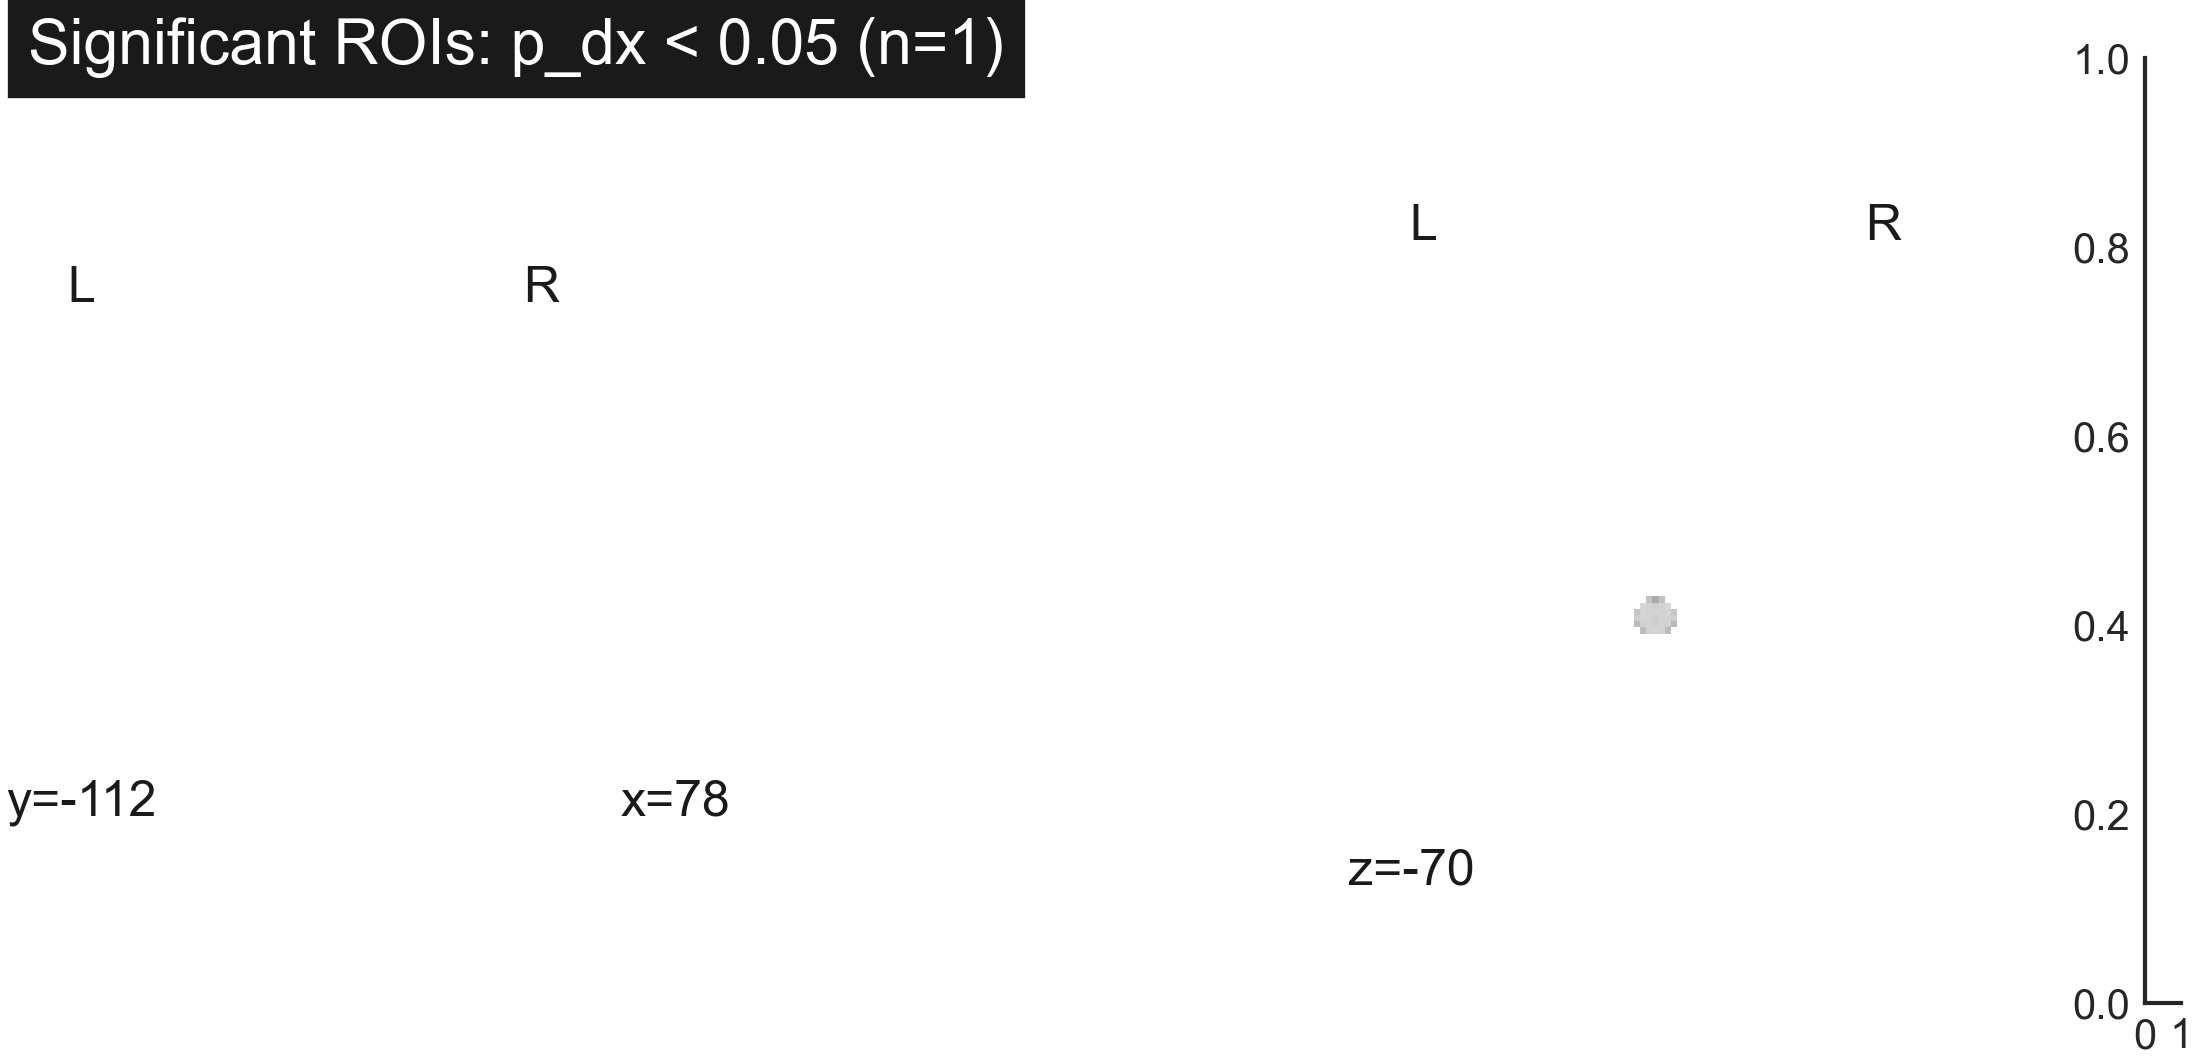

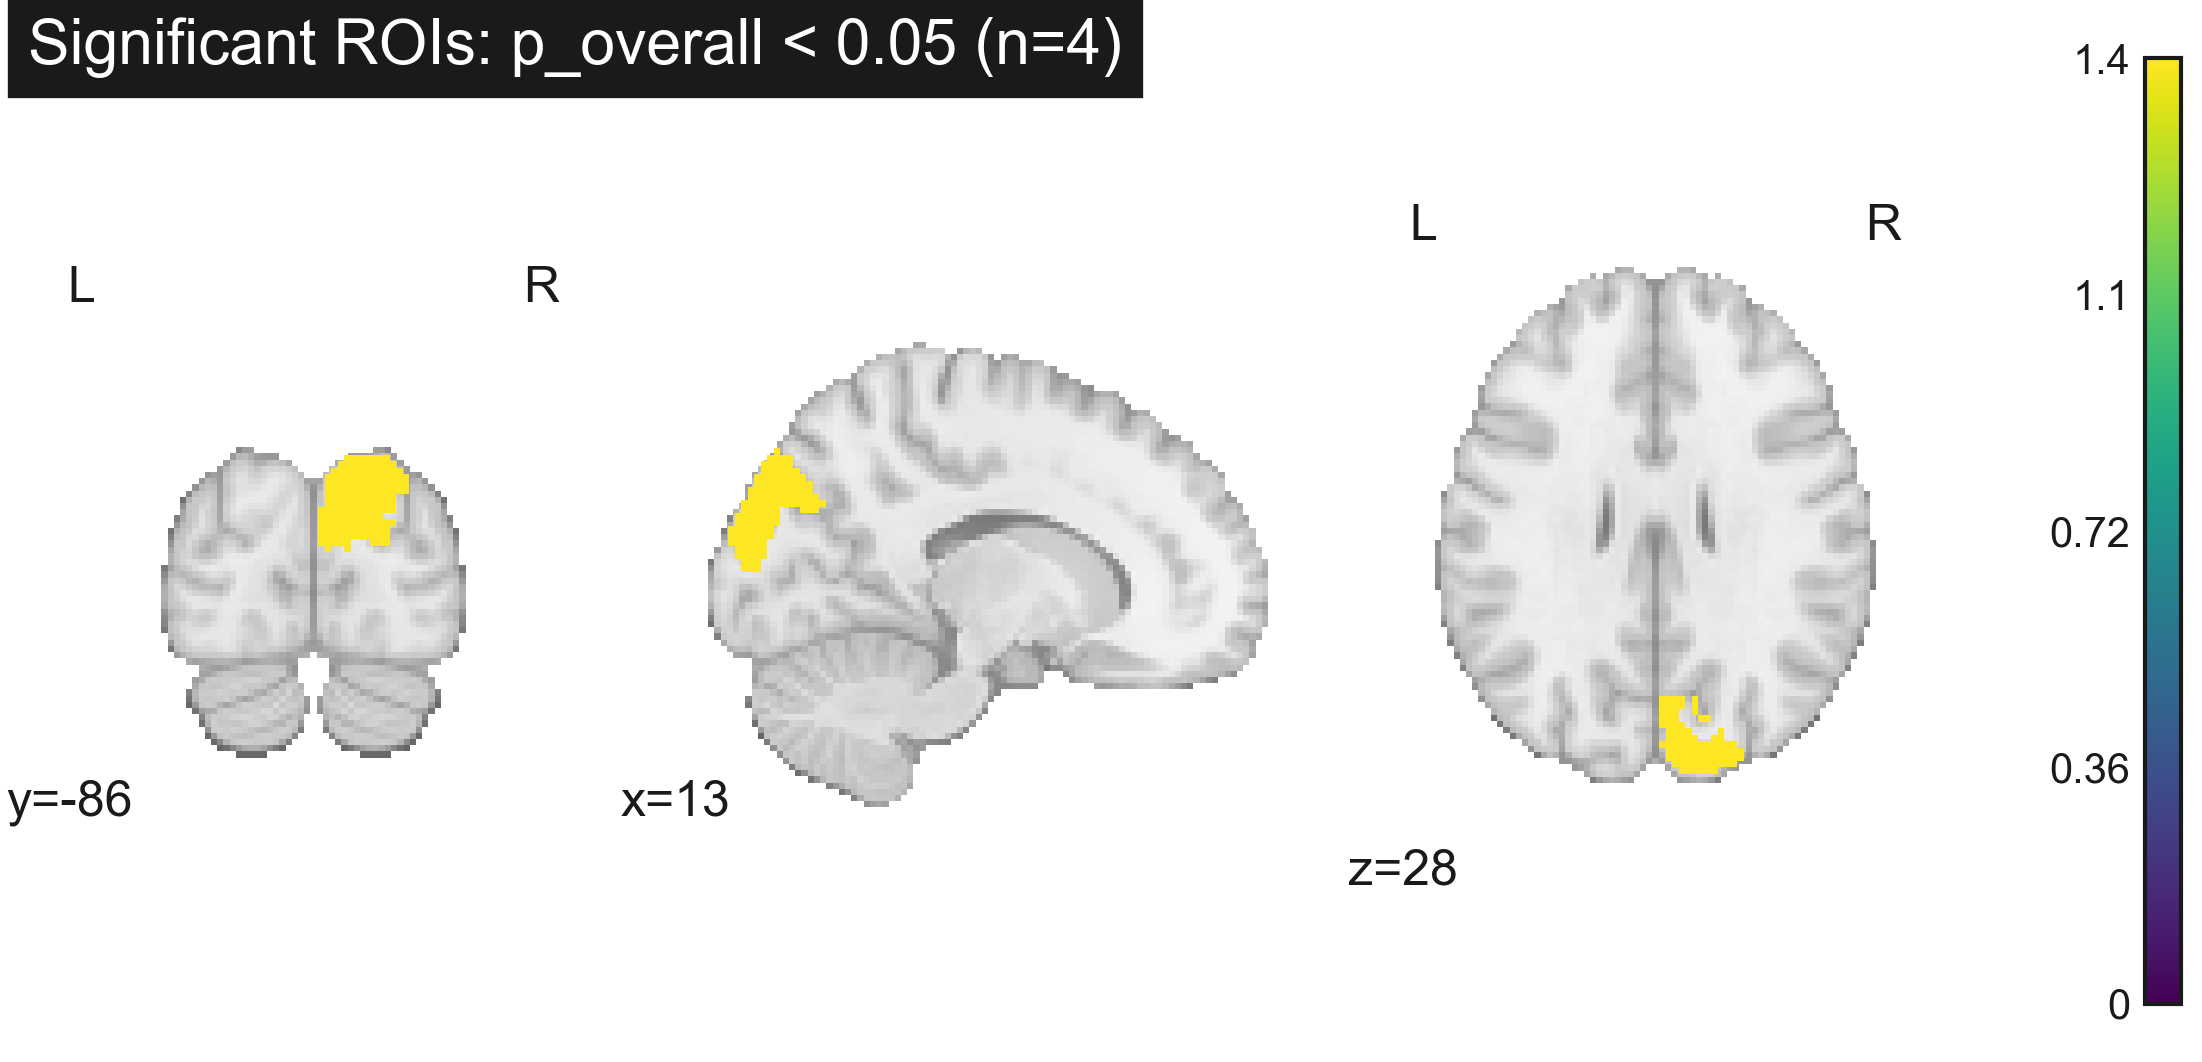

In [16]:
def organize_by_character(data, char_roles, *, chars=None):
    """
    Split trialwise data into per-character chunks using an explicit role vector.

    Parameters
    ----------
    data : np.ndarray or pd.DataFrame
        Trialwise data aligned to `char_roles` (after any dropping/filtering).
    char_roles : array-like (T,)
        Character role per trial, aligned to rows of `data`.
    chars : sequence, optional
        Which character IDs to return, in order. If None, inferred from char_roles.

    Returns
    -------
    list
        List of data slices, one per character in `chars`.
    """
    char_roles = np.asarray(char_roles)
    T = len(char_roles)

    if isinstance(data, pd.DataFrame):
        if len(data) != T:
            raise ValueError(f"len(data)={len(data)} != len(char_roles)={T}")
        if chars is None:
            chars = sorted(pd.unique(char_roles))
        return [data.loc[char_roles == c].reset_index(drop=True) for c in chars]

    data = np.asarray(data)
    if data.shape[0] != T:
        raise ValueError(f"data.shape[0]={data.shape[0]} != len(char_roles)={T}")
    if chars is None:
        chars = sorted(np.unique(char_roles))
    if data.ndim == 1:
        return [data[char_roles == c] for c in chars]
    return [data[char_roles == c, :] for c in chars]

def _charpair_mean_time(onsets_by_char):
    """
    |mean_onset_i - mean_onset_j| over character means -> RDV over character pairs.
    Assumes each character has the same number of trials (no special handling).
    """
    mu = np.array([np.mean(t) for t in onsets_by_char], float)
    return pdist(mu[:, None], metric="euclidean")

def charpair_mean_position_distance(loc_by_char):
    """
    Euclidean distance between mean social positions of characters.
    loc_by_char: list of (T, 2) arrays
    """
    means = np.array([x.mean(axis=0) for x in loc_by_char])
    return pdist(means, metric="euclidean")

def charpair_mean_trajectory_distance(loc_by_char):
    """
    Mean Euclidean distance between two trajectories across time.
    Assumes equal trial counts across characters.
    """
    n = len(loc_by_char)
    dists = []

    for i in range(n):
        for j in range(i + 1, n):
            dij_t = np.linalg.norm(loc_by_char[i] - loc_by_char[j], axis=1)
            dists.append(dij_t.mean())

    return np.array(dists)

def run_character_position_rsa(all_data, chars=(1, 2, 3, 4, 5)):
    """
    Characters-as-items RSA:
      Neural(char_i vs char_j) ~ MeanPositionDist(char_i vs char_j) + TimeDist
    """

    def _get_roi_code_to_label(sd: dict) -> dict[int, str]:
        if "atlas" in sd and isinstance(sd["atlas"], dict) and "rois" in sd["atlas"]:
            rois = sd["atlas"]["rois"]
            if isinstance(rois, dict):
                try:
                    return {int(k): str(v) for k, v in rois.items()}
                except Exception:
                    pass
        if "roi_labels" in sd and isinstance(sd["roi_labels"], dict):
            rois = sd["roi_labels"]
            try:
                return {int(k): str(v) for k, v in rois.items()}
            except Exception:
                pass
        return {}

    def _normalize_roi_name(roi_key, code_to_label: dict[int, str]) -> str:
        if isinstance(roi_key, str):
            return roi_key
        try:
            k = int(roi_key)
        except Exception:
            return str(roi_key)
        return code_to_label.get(k, str(k))

    rows = []

    for sub_id, sd in all_data.items():
        if ("behavior" not in sd) or ("roi_betas" not in sd) or ("char_roles" not in sd):
            continue

        behav = sd["behavior"]
        rois  = sd["roi_betas"]
        roles = sd["char_roles"]

        # --- social positions by character ---
        loc_by_char = organize_by_character(
            behav[["affil_coord", "power_coord"]].values,
            roles,
            chars=chars,
        )
        rdv_social = charpair_mean_position_distance(loc_by_char)

        # --- time control ---
        onsets_by_char = organize_by_character(
            behav["onset"].values, roles, chars=chars
        )
        rdv_time = _charpair_mean_time(onsets_by_char)

        # --- ROI name normalization mapping (code -> label) ---
        code_to_label = _get_roi_code_to_label(sd)

        # --- per ROI ---
        for roi_key, betas in rois.items():
            roi_name = _normalize_roi_name(roi_key, code_to_label)

            betas_by_char = organize_by_character(
                np.asarray(betas), roles, chars=chars
            )

            neural_feat = np.vstack([b.reshape(1, -1) for b in betas_by_char])
            neural_rdv  = pdist(neural_feat, metric="correlation")

            stats = fit_rsa_regression(
                neural_rdv,
                design_rdvs={"mean_pos": rdv_social},
                nuisance_rdvs={"time_char": rdv_time},
            )

            rows.append({
                "sub_id": sub_id,
                "roi": roi_name,
                "beta": stats["beta_mean_pos"],
                "t_stat": stats["t_mean_pos"],
                "p_val": stats["p_mean_pos"],
                "r2_adj": stats["R2_adj"],
            })

    return pd.DataFrame(rows)

def run_character_mean_trajectory_rsa(all_data, chars=(1, 2, 3, 4, 5)):
    """
    Characters-as-items RSA:
      Neural(char_i vs char_j) ~ MeanTrajectoryDist(char_i vs char_j) + TimeDist
    """

    def _get_roi_code_to_label(sd: dict) -> dict[int, str]:
        if "atlas" in sd and isinstance(sd["atlas"], dict) and "rois" in sd["atlas"]:
            rois = sd["atlas"]["rois"]
            if isinstance(rois, dict):
                try:
                    return {int(k): str(v) for k, v in rois.items()}
                except Exception:
                    pass
        if "roi_labels" in sd and isinstance(sd["roi_labels"], dict):
            rois = sd["roi_labels"]
            try:
                return {int(k): str(v) for k, v in rois.items()}
            except Exception:
                pass
        return {}

    def _normalize_roi_name(roi_key, code_to_label: dict[int, str]) -> str:
        if isinstance(roi_key, str):
            return roi_key
        try:
            k = int(roi_key)
        except Exception:
            return str(roi_key)
        return code_to_label.get(k, str(k))

    rows = []

    for sub_id, sd in all_data.items():
        if ("behavior" not in sd) or ("roi_betas" not in sd) or ("char_roles" not in sd):
            continue

        behav = sd["behavior"]
        rois  = sd["roi_betas"]
        roles = sd["char_roles"]

        # --- social trajectories ---
        loc_by_char = organize_by_character(
            behav[["affil_coord", "power_coord"]].values,
            roles,
            chars=chars,
        )
        rdv_social = charpair_mean_trajectory_distance(loc_by_char)

        # --- time control ---
        onsets_by_char = organize_by_character(
            behav["onset"].values, roles, chars=chars
        )
        rdv_time = _charpair_mean_time(onsets_by_char)

        # --- ROI name normalization mapping (code -> label) ---
        code_to_label = _get_roi_code_to_label(sd)

        # --- per ROI ---
        for roi_key, betas in rois.items():
            roi_name = _normalize_roi_name(roi_key, code_to_label)

            betas_by_char = organize_by_character(
                np.asarray(betas), roles, chars=chars
            )

            neural_feat = np.vstack([b.reshape(1, -1) for b in betas_by_char])
            neural_rdv  = pdist(neural_feat, metric="correlation")

            stats = fit_rsa_regression(
                neural_rdv,
                design_rdvs={"mean_traj": rdv_social},
                nuisance_rdvs={"time_char": rdv_time},
            )

            rows.append({
                "sub_id": sub_id,
                "roi": roi_name,
                "beta": stats["beta_mean_traj"],
                "t_stat": stats["t_mean_traj"],
                "p_val": stats["p_mean_traj"],
                "r2_adj": stats["R2_adj"],
            })

    return pd.DataFrame(rows)


#-------------------------- average location distance

# df_rsa = run_character_position_rsa(subject_data)
# df_rsa = df_rsa.merge(data, on='sub_id', how='left')
res_df = roi_group_tests(df_rsa)

plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_dx');
plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_ctq');
plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_overall');

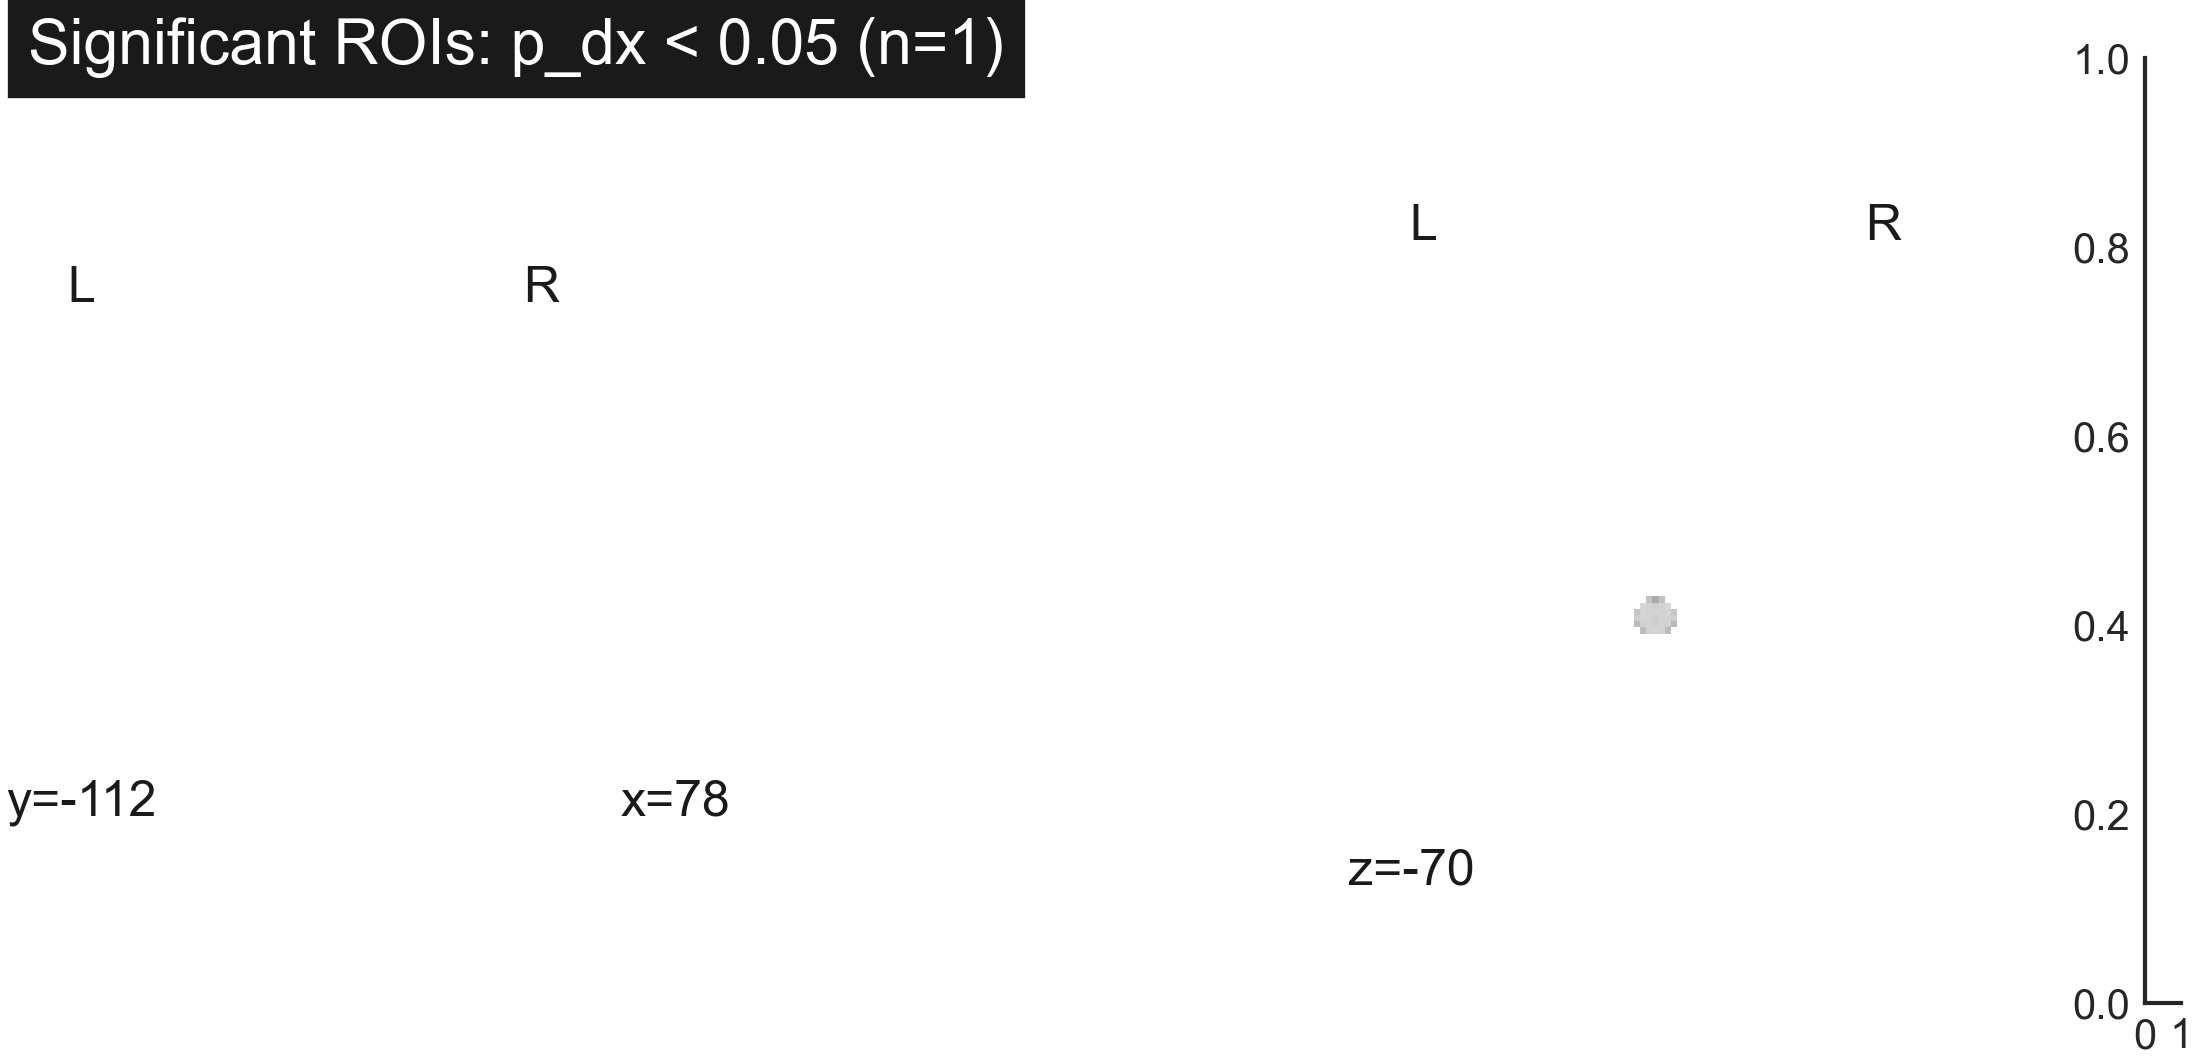

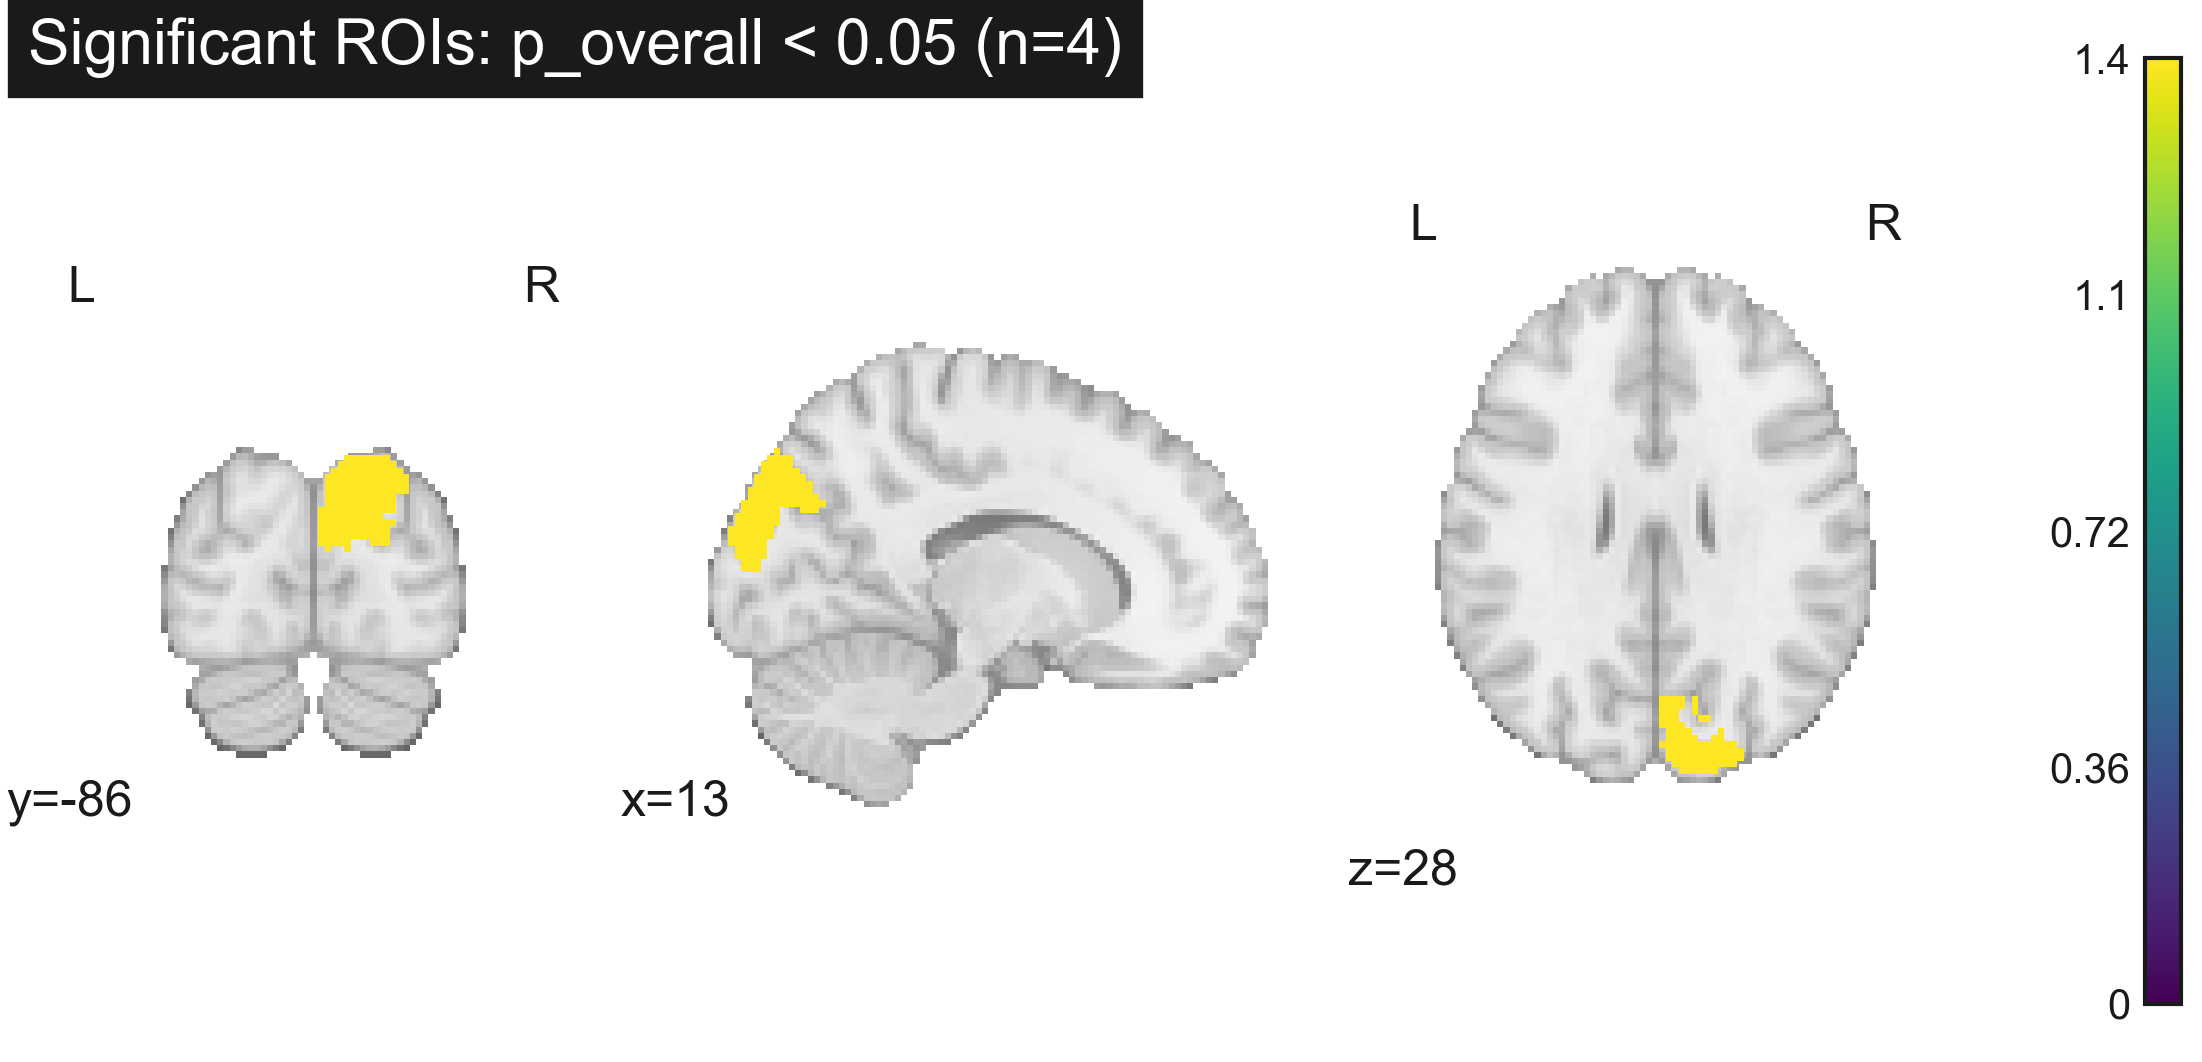

In [15]:
#-------------------------- average trajectory distance

# df_rsa = run_character_mean_trajectory_rsa(subject_data)
# df_rsa = df_rsa.merge(data, on='sub_id', how='left')
res_df = roi_group_tests(df_rsa)

plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_dx');
plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_ctq');
plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_overall');

<h1 align='center'> Relationship history matters (w/ semantic embeddings)</h1>

In [ ]:
def run_embedding_rsa(
    all_data,
    emb_key="embds_ctxt",
    *,
    chars=(1, 2, 3, 4, 5),
    role_col="character_role_num",
):
    """
    Trialwise RSA:
      Neural distance ~ Cosine(embeddings)
                       + TimeDist + TimeDist^2
                       + (within-character indicators for each character)

    Character controls:
      For each character c in `chars`, adds an RDV that is 1 for pairs where
      both trials are character c, else 0.
    """

    def _pairwise_both_one(indicator_01: np.ndarray) -> np.ndarray:
        v = np.asarray(indicator_01, int).reshape(-1)
        T = v.size
        M = np.logical_and(v[:, None] == 1, v[None, :] == 1).astype(float)
        iu = np.triu_indices(T, k=1)
        return M[iu]

    def _get_roi_code_to_label(sd: dict) -> dict[int, str]:
        """
        Best-effort mapping from ROI integer code -> ROI label string.
        Looks for sd["atlas"]["rois"] (dict) or sd["roi_labels"] (dict).
        Returns {} if not available.
        """
        # Preferred: sd["atlas"]["rois"] where rois is dict[code] = label
        if "atlas" in sd and isinstance(sd["atlas"], dict) and "rois" in sd["atlas"]:
            rois = sd["atlas"]["rois"]
            if isinstance(rois, dict):
                try:
                    return {int(k): str(v) for k, v in rois.items()}
                except Exception:
                    pass

        # Fallback: user-provided mapping
        if "roi_labels" in sd and isinstance(sd["roi_labels"], dict):
            rois = sd["roi_labels"]
            try:
                return {int(k): str(v) for k, v in rois.items()}
            except Exception:
                pass

        return {}

    def _normalize_roi_name(roi_key, code_to_label: dict[int, str]) -> str:
        """
        If roi_key looks like an integer code and we have a mapping, return label.
        Otherwise return roi_key as a string.
        """
        # already a string label
        if isinstance(roi_key, str):
            return roi_key

        # integer-ish atlas code
        try:
            k = int(roi_key)
        except Exception:
            return str(roi_key)

        return code_to_label.get(k, str(k))

    rows = []

    for sub_id, sd in all_data.items():
        if ("behavior" not in sd) or ("roi_betas" not in sd) or (emb_key not in sd):
            continue

        behav = sd["behavior"]
        rois  = sd["roi_betas"]
        Xemb  = np.asarray(sd[emb_key], float)  # (T, D)

        if "onset" not in behav.columns:
            raise ValueError(f"Sub {sub_id} missing 'onset' in behavior.")
        if role_col not in behav.columns:
            raise ValueError(f"Sub {sub_id} missing '{role_col}' in behavior.")

        T = len(behav)
        if Xemb.shape[0] != T:
            raise ValueError(f"Sub {sub_id} embedding trials {Xemb.shape[0]} != behavior trials {T}")

        # --- core RDVs (embeddings + time) ---
        rdvs = compute_flexible_rdvs(
            {
                "emb": Xemb,
                "time": behav["onset"].to_numpy(float),
            },
            metric_dict={
                "emb": "cosine",
                "time": "euclidean",   # -> |Δt|
            },
        )

        time_rdv  = rdvs["time"]
        time2_rdv = time_rdv ** 2

        # --- character identity nuisance RDVs (within-character) ---
        roles = behav[role_col].to_numpy()
        char_nuis = {}
        for c in chars:
            ind = (roles == c).astype(int)  # (T,)
            char_nuis[f"char{c}_within"] = _pairwise_both_one(ind)

        # --- ROI name normalization mapping (code -> label) ---
        code_to_label = _get_roi_code_to_label(sd)

        for roi_key, betas in rois.items():
            roi_name = _normalize_roi_name(roi_key, code_to_label)
            betas = np.asarray(betas, float)  # (T, V)

            if betas.shape[0] != T:
                raise ValueError(
                    f"Trial mismatch sub {sub_id}, roi {roi_name}: betas={betas.shape[0]}, behav={T}"
                )

            neural_rdv = pdist(betas, metric="correlation")

            nuisance = {"time": time_rdv, "time2": time2_rdv}
            nuisance.update(char_nuis)

            stats = fit_rsa_regression(
                neural_rdv,
                design_rdvs={"emb": rdvs["emb"]},
                nuisance_rdvs=nuisance,
            )

            rows.append({
                "sub_id": sub_id,
                "roi": roi_name,
                "beta": stats["beta_emb"],
                "t_stat": stats["t_emb"],
                "p_val": stats["p_emb"],
                "r2_adj": stats["R2_adj"],
            })

    return pd.DataFrame(rows)

df_ctxt = run_embedding_rsa(subject_data, emb_key="embds_ctxt")
df_ctxt["emb_type"] = "ctxt"
df_noctxt = run_embedding_rsa(subject_data, emb_key="embds_noctxt")
df_noctxt["emb_type"] = "noctxt"

In [ ]:
df_pair = (
    df_ctxt
    .merge(
        df_noctxt,
        on=["sub_id", "roi"],
        suffixes=("_ctxt", "_noctxt"),
        how="inner",
    )
)
df_pair["delta_beta"] = df_pair["beta_ctxt"] - df_pair["beta_noctxt"]
df_pair = df_pair.merge(data, on='sub_id', how='left')
res_df = roi_group_tests(df_pair, y_col="delta_beta", demo_controls=("sex", "fd_mean", "memory_mean"))
# print_df(res_df.sort_values('p_dx').head(20))
# print_df(res_df.sort_values('p_ctq').head(10))
plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_dx');
plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_ctq');

In [ ]:
df_pair_hipp = df_pair[df_pair['roi']== 'Right Hippocampus']
df_pair_pcc  = df_pair[df_pair['roi']== '7Networks_RH_Default_pCunPCC_1']
df_pair_att = df_pair[df_pair["roi"] == '7Networks_LH_SalVentAttn_FrOperIns_1']

print_df(run_regression('delta_beta ~ ctq_score + dx + memory_mean + sex + fd_mean', data=df_pair_hipp))
print_df(run_regression('delta_beta ~ ctq_score + dx + memory_mean + sex + fd_mean', data=df_pair_pcc))
print_df(run_regression('delta_beta ~ ctq_score + dx + memory_mean + sex + fd_mean', data=df_pair_att))

### does this relate to functional connectivity?

In [ ]:
from scipy.stats import pearsonr

def _nan_zscore(x, eps=1e-12):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    if m.sum() < 2:
        return x * np.nan
    mu = np.nanmean(x[m])
    sd = np.nanstd(x[m])
    return (x - mu) / (sd + eps)

def roi_beta_series(roi_mat, *, summary="mean", n_pc=1):
    """
    roi_mat: (T, V) beta series patterns for one ROI.
    Returns: (T,) (or (T, n_pc) if summary="pca" and n_pc>1)
    """
    X = np.asarray(roi_mat, float)
    if X.ndim != 2 or X.shape[0] < 2 or X.shape[1] < 1:
        return np.full((X.shape[0],), np.nan, float)

    # Drop trials with any NaNs across voxels (consistent with your voxel NaN dropping)
    good_t = np.isfinite(X).all(axis=1)
    Xg = X[good_t]
    if Xg.shape[0] < 2:
        return np.full((X.shape[0],), np.nan, float)

    if summary == "mean":
        s = Xg.mean(axis=1)

    elif summary == "median":
        s = np.median(Xg, axis=1)

    elif summary == "pca":
        # PCA over voxels (V) using SVD on mean-centered trials
        Xc = Xg - Xg.mean(axis=0, keepdims=True)
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        # trial scores for top components
        k = int(n_pc)
        k = max(1, min(k, U.shape[1]))
        scores = U[:, :k] * S[:k]  # (Tgood, k)
        s = scores if k > 1 else scores[:, 0]

    else:
        raise ValueError("summary must be one of {'mean','median','pca'}")

    # Put back into full-length T with NaNs for bad trials
    out = np.full((X.shape[0],) + (() if np.ndim(s) == 1 else (s.shape[1],)), np.nan, float)
    out[good_t] = s
    return out

def beta_series_connectivity(x, y, *, method="pearson", zscore=True, min_T=10):
    """
    x,y: (T,) vectors (trialwise beta series) for two ROIs.
    Returns r, z, n_used
    """
    x = np.asarray(x, float).reshape(-1)
    y = np.asarray(y, float).reshape(-1)
    m = np.isfinite(x) & np.isfinite(y)
    n = int(m.sum())
    if n < min_T:
        return np.nan, np.nan, n

    xx = x[m]; yy = y[m]
    if zscore:
        xx = _nan_zscore(xx)
        yy = _nan_zscore(yy)

    if method == "pearson":
        r = pearsonr(xx, yy).statistic
    else:
        raise ValueError("method must be 'pearson'")

    # Fisher z (guard bounds)
    r_clip = np.clip(r, -0.999999, 0.999999)
    z = np.arctanh(r_clip)
    return float(r), float(z), n

def subject_roi_pair_fc(
    subj_dict,
    roi_a,
    roi_b,
    *,
    summary="mean",      # "mean" (recommended to start), or "pca"
    n_pc=1,
    min_T=10,
):
    roi_betas = subj_dict["roi_betas"]
    if roi_a not in roi_betas or roi_b not in roi_betas:
        return {"r": np.nan, "z": np.nan, "n": 0}

    Xa = roi_betas[roi_a]  # (T,V)
    Xb = roi_betas[roi_b]

    sa = roi_beta_series(Xa, summary=summary, n_pc=n_pc)
    sb = roi_beta_series(Xb, summary=summary, n_pc=n_pc)

    # If PCA with k>1 yields (T,k), you need multivariate connectivity.
    # For simplicity: use first component if multivariate.
    if sa.ndim > 1: sa = sa[:, 0]
    if sb.ndim > 1: sb = sb[:, 0]

    r, z, n = beta_series_connectivity(sa, sb, min_T=min_T)
    return {"r": r, "z": z, "n": n}

def run_fc_across_subjects(subject_data, roi_a, roi_b, *, summary="mean", n_pc=1, min_T=10):
    rows = []
    for sid, sdict in subject_data.items():
        out = subject_roi_pair_fc(sdict, roi_a, roi_b, summary=summary, n_pc=n_pc, min_T=min_T)
        rows.append({"sub_id": sid, "roi_a": roi_a, "roi_b": roi_b, **out})
    return pd.DataFrame(rows)

roi_1 = 'Right Hippocampus'
roi_2 = '7Networks_RH_Default_pCunPCC_1'
roi_3 = '7Networks_LH_SalVentAttn_FrOperIns_1'

fc_df = run_fc_across_subjects(subject_data, roi_1, roi_2, summary="mean")
fc_df = fc_df.merge(data, on='sub_id', how='left')
print_df(run_regression('z ~ ctq_score + dx + memory_mean + sex + fd_mean', data=fc_df))


### does it predict subjective placement?
try different ways of assessing this... 
- e.g. nearest neighbor assessment, etc...

In [ ]:
# does any region relate to dots?
rois = df_pair['roi'].unique()
for roi in rois:
    df_pair_roi = df_pair[df_pair['roi']==roi]
    res = run_regression('beh_dots_dist_zscore ~ delta_beta + memory_mean + fd_mean', data=df_pair_roi)
    res = res[res['x']=='delta_beta'][['beta', 'p_left']]
    if res['p_left'].values < 0.05:
        print(f"ROI: {roi}, beta: {res['beta'].values[0]:.4f}, p: {res['p_left'].values[0]:.4f}")

print_df(run_regression('beh_dots_dist_zscore ~ delta_beta + memory_mean + fd_mean', data=df_pair_hipp))
print_df(run_regression('beh_dots_dist_zscore ~ delta_beta + memory_mean + fd_mean', data=df_pair_pcc))
print_df(run_regression('beh_dots_dist_zscore ~ delta_beta + memory_mean + fd_mean', data=df_pair_att))

### Does it predict real world social behaviors?

More years of use predicts more use of context, counter-intuitively

Do we have any self-reports that reflect something like lenght of relationships etc..? maybe SNI?

Maybe can relate to mentalizing?

In [ ]:
# cocaine related variables
df_pair_hipp_cd = df_pair_hipp[df_pair_hipp['dx']=='CD'] 
df_pair_pcc_cd = df_pair_pcc[df_pair_pcc['dx']=='CD'] 
print_df(run_regression('delta_beta ~ memory_mean + fd_mean + frac_yrs_using + age_years + asi_coc_pastmonth + screen_utox___coc + wrat_t_score', data=df_pair_hipp_cd))
print_df(run_regression('beh_dots_dist_zscore ~ memory_mean + fd_mean + frac_yrs_using + age_years + asi_coc_pastmonth + screen_utox___coc + wrat_t_score', data=df_pair_hipp_cd))

<h1 align='center'> The social space: what is shared across characters </h1>

Want to find the information specific to a character as well as the information shared across... want to show that in both cases it's interesting structure

In [ ]:
def _upper_tri_indices(T):
    return np.triu_indices(T, k=1)

def _upper_tri_mask_from_roles(roles):
    """Return boolean masks (within, between) for upper-triangle pairs."""
    roles = np.asarray(roles)
    T = roles.size
    iu = _upper_tri_indices(T)
    same = (roles[iu[0]] == roles[iu[1]])
    return same, ~same

def _zscore_full(x, eps=1e-12):
    """Z-score a full RDV (across ALL pairs) once per subject for comparability."""
    x = np.asarray(x, float)
    m = np.isfinite(x)
    if m.sum() < 2:
        return x
    mu = np.mean(x[m])
    sd = np.std(x[m])
    return (x - mu) / (sd + eps)

def _residualize_1d(y, x):
    """
    Residualize y on x (both 1D arrays, same length), using OLS with intercept.
    Returns residuals with NaNs preserved where either is non-finite.
    """
    y = np.asarray(y, float)
    x = np.asarray(x, float)
    m = np.isfinite(y) & np.isfinite(x)
    out = np.full_like(y, np.nan, dtype=float)
    if m.sum() < 3:
        return out
    X = sm.add_constant(x[m])
    fit = sm.OLS(y[m], X).fit()
    out[m] = y[m] - fit.fittedvalues
    return out

def _fit_rsa_on_mask(neural_rdv, design_rdvs, nuisance_rdvs, mask):
    """
    Fit RSA regression using only entries where mask==True.
    NOTE: predictors are assumed to already be on a common scale across masks
          (i.e., z-scored globally across all pairs, not within-mask).
    """
    y = np.asarray(neural_rdv, float)[mask]

    X_data = {}
    for name, rdv in {**nuisance_rdvs, **design_rdvs}.items():
        X_data[name] = np.asarray(rdv, float)[mask]

    X = sm.add_constant(pd.DataFrame(X_data))
    res = sm.OLS(y, X).fit()

    out = {"R2_adj": float(res.rsquared_adj), "N_pairs": int(mask.sum())}
    for name in design_rdvs:
        out[f"beta_{name}"] = float(res.params.get(name, np.nan))
        out[f"t_{name}"]    = float(res.tvalues.get(name, np.nan))
        out[f"p_{name}"]    = float(res.pvalues.get(name, np.nan))
    return out

# ----------------------------
# Main analysis
# ----------------------------

def run_embedding_rsa_within_between_corrected(
    all_data,
    emb_key="embds_ctxt",
    *,
    role_col="character_role_num",
    onset_col="onset",
    map_cols=("affil_coord", "power_coord"),
    add_run_nuisance=True,          # adds run mismatch nuisance if behav has "run"
    residualize_emb_on_map=False,   # if True, uses emb_resid = emb ⟂ map (recommended if emb and map are correlated)
):
    """
    For each subject and ROI, fit two RSA feature-extraction models:
      (A) within-character trial pairs
      (B) between-character trial pairs

    Model (per subset):
      NeuralRDV ~ map + emb (+ time + time^2 [+ run_mismatch])

    Corrections vs original:
      1) Predictors are z-scored ONCE across ALL pairs (per subject), then subset by mask.
         This makes beta_map/beta_emb comparable across within vs between.
      2) Optional run-mismatch nuisance if 'run' exists in behavior.
      3) Optional explicit residualization of emb RDV on map RDV for interpretability.
    """
    rows = []

    for sub_id, sd in all_data.items():
        if ("behavior" not in sd) or ("roi_betas" not in sd) or (emb_key not in sd):
            continue

        behav = sd["behavior"]
        rois  = sd["roi_betas"]

        if role_col not in behav.columns:
            raise ValueError(f"Sub {sub_id} missing {role_col}")

        roles = behav[role_col].to_numpy()

        required = [onset_col, *map_cols]
        miss = [c for c in required if c not in behav.columns]
        if miss:
            raise ValueError(f"Sub {sub_id} missing columns: {miss}")

        Xemb = np.asarray(sd[emb_key], float)  # (T, D)
        T = len(behav)
        if Xemb.shape[0] != T:
            raise ValueError(f"Sub {sub_id}: embeddings trials {Xemb.shape[0]} != behavior trials {T}")

        # Pair masks
        mask_within, mask_between = _upper_tri_mask_from_roles(roles)

        # --- Predictor RDVs (full, across ALL pairs) ---
        emb_rdv   = pdist(Xemb, metric="cosine")
        time_rdv  = pdist(behav[onset_col].to_numpy(float)[:, None], metric="euclidean")
        time2_rdv = time_rdv ** 2
        map_rdv   = pdist(behav[list(map_cols)].to_numpy(float), metric="euclidean")

        # Optional run mismatch nuisance (0 within-run, 1 across-run)
        nuisance = {}
        if add_run_nuisance and ("run" in behav.columns):
            run = behav["run"].to_numpy()
            run_rdv = pdist(run[:, None], metric="euclidean")
            run_mismatch = (run_rdv > 0).astype(float)
            nuisance["run_mismatch"] = _zscore_full(run_mismatch)

        # Global z-scoring ONCE per subject (critical for within/between comparability)
        map_z   = _zscore_full(map_rdv)
        emb_z   = _zscore_full(emb_rdv)
        time_z  = _zscore_full(time_rdv)
        time2_z = _zscore_full(time2_rdv)

        nuisance.update({"time": time_z, "time2": time2_z})

        if residualize_emb_on_map:
            emb_resid = _residualize_1d(emb_z, map_z)
            design = {"map": map_z, "emb_resid": emb_resid}
        else:
            design = {"map": map_z, "emb": emb_z}

        # --- Per ROI ---
        for roi_name, betas in rois.items():
            betas = np.asarray(betas, float)
            if betas.ndim != 2:
                raise ValueError(f"Sub {sub_id}, roi {roi_name}: expected 2D (T,V), got {betas.shape}")
            if betas.shape[0] != T:
                raise ValueError(f"Trial mismatch sub {sub_id}, roi {roi_name}: {betas.shape[0]} vs {T}")

            # Neural RDV: correlation distance between trial patterns
            neural_rdv = pdist(betas, metric="correlation")

            # within-character
            st_w = _fit_rsa_on_mask(neural_rdv, design, nuisance, mask_within)
            rows.append({
                "sub_id": sub_id,
                "roi": roi_name,
                "pair_set": "within_char",
                "emb_key": emb_key,
                "residualize_emb_on_map": bool(residualize_emb_on_map),
                "has_run_nuisance": bool(add_run_nuisance and ("run" in behav.columns)),
                **st_w,
            })

            # between-character
            st_b = _fit_rsa_on_mask(neural_rdv, design, nuisance, mask_between)
            rows.append({
                "sub_id": sub_id,
                "roi": roi_name,
                "pair_set": "between_char",
                "emb_key": emb_key,
                "residualize_emb_on_map": bool(residualize_emb_on_map),
                "has_run_nuisance": bool(add_run_nuisance and ("run" in behav.columns)),
                **st_b,
            })

    return pd.DataFrame(rows)

# ----------------------------
# Example usage (mirrors your pipeline)
# ----------------------------

df_ctxt_split = run_embedding_rsa_within_between_corrected(
    subject_data,
    emb_key="embds_ctxt",
    role_col="character_role_num",
    add_run_nuisance=True,
    residualize_emb_on_map=False,   # set True if you want emb ⟂ map explicitly
)
df_ctxt_split["emb_type"] = "ctxt"

df_noctxt_split = run_embedding_rsa_within_between_corrected(
    subject_data,
    emb_key="embds_noctxt",
    role_col="character_role_num",
    add_run_nuisance=True,
    residualize_emb_on_map=False,
)
df_noctxt_split["emb_type"] = "noctxt"

df_split = pd.concat([df_ctxt_split, df_noctxt_split], ignore_index=True)
df_split = df_split.merge(data, on="sub_id", how="left")

In [ ]:
# Pivot to wide format: one row per subject × ROI × pair_set
df_wide = (
    df_split
    .pivot_table(
        index=["sub_id", "roi", "pair_set"],
        columns="emb_type",
        values="beta_map",   # or "beta_emb" if you want embedding effects
        aggfunc="mean"
    )
    .reset_index()
)
df_wide["delta_beta"] = df_wide["ctxt"] - df_wide["noctxt"]
df_wide = df_wide.merge(data, on="sub_id", how="left")

# within character pairs
df_delta_within = df_wide[df_wide["pair_set"] == "within_char"]
res_within = roi_group_tests(
    df_delta_within,
    y_col="delta_beta",
    demo_controls=("sex", "fd_mean", "memory_mean")
)
print_df(res_within.sort_values("p_dx").head(10))

# between character pairs
df_delta_between = df_wide[df_wide["pair_set"] == "between_char"]
res_between = roi_group_tests(
    df_delta_between,
    y_col="delta_beta",
    demo_controls=("sex", "fd_mean", "memory_mean")
)
print_df(res_between.sort_values("p_dx").head(10))

## does between character mapping related to dots?

In [ ]:
# does the between character effect in any region relate to dots?
rois = df_delta_between['roi'].unique()
for roi in rois:
    df  = df_delta_between[df_delta_between['roi']==roi]
    res = run_regression('beh_dots_dist_zscore ~ delta_beta + ctq_score + dx + memory_mean + fd_mean', data=df)
    res = res[res['x']=='delta_beta'][['beta', 'p_left']]
    if res['p_left'].values < 0.05:
        print(f"ROI: {roi}, beta: {res['beta'].values[0]:.4f}, p: {res['p_left'].values[0]:.4f}")

In [ ]:
df = df_delta_between[df_delta_between['roi']=='7Networks_RH_Default_pCunPCC_1']
df = df_delta_between[df_delta_between['roi']=='Right Hippocampus']

sns.regplot(
    data=df,
    x='delta_beta',
    y='beh_dots_dist_zscore',
)

##  IS-RSA

In [ ]:
from scipy.stats import rankdata

def roi_between_subject_similarity_from_rdms(subject_data, roi_name, sub_ids=None, *, metric="correlation", rank=True):
    """
    For a given ROI, compute between-subject similarity based on each subject's
    trialwise RDM vector (voxel-invariant).

    Returns
    -------
    sim_vec : (n_pairs,) vector = upper-triangular of subject-subject similarity matrix
    sub_ids_used : list of sub_ids aligned to the similarity matrix
    """
    if sub_ids is None:
        sub_ids = list(subject_data.keys())

    rdm_vecs = []
    kept = []

    for sid in sub_ids:
        sd = subject_data.get(sid, None)
        if sd is None or "roi_betas" not in sd:
            continue
        if roi_name not in sd["roi_betas"]:
            continue

        X = np.asarray(sd["roi_betas"][roi_name], float)  # (T, V)
        if X.ndim != 2 or X.shape[0] < 3 or X.shape[1] < 1:
            continue

        # Trial RDM is (T,T); does NOT depend on voxel count beyond defining distances
        rdm = pairwise_distances(X, metric=metric)  # correlation distance
        v = flatten_upper_tri(rdm)

        # Optional rank-transform per subject before between-subject corr (matches your prior)
        if rank:
            v = rankdata(v)

        rdm_vecs.append(v)
        kept.append(sid)

    if len(rdm_vecs) < 3:
        return np.array([]), kept

    rdm_vecs = np.vstack(rdm_vecs)              # (n_sub, n_edges)
    sim_mat  = np.corrcoef(rdm_vecs)            # (n_sub, n_sub)
    sim_vec  = flatten_upper_tri(sim_mat)       # (n_pairs,)

    return sim_vec, kept

def embedding_between_subject_similarity_from_rdms(subject_data, sub_ids=None, *, emb_key="embds_ctxt", metric="cosine", rank=True):
    """
    Between-subject similarity based on each subject's trialwise embedding RDM vector.
    """
    if sub_ids is None:
        sub_ids = list(subject_data.keys())

    rdm_vecs = []
    kept = []

    for sid in sub_ids:
        sd = subject_data.get(sid, None)
        if sd is None or emb_key not in sd:
            continue

        E = np.asarray(sd[emb_key], float)      # (T, D)
        if E.ndim != 2 or E.shape[0] < 3:
            continue

        rdm = pairwise_distances(E, metric=metric)  # cosine distance on embeddings
        v = flatten_upper_tri(rdm)

        if rank:
            v = rankdata(v)

        rdm_vecs.append(v)
        kept.append(sid)

    if len(rdm_vecs) < 3:
        return np.array([]), kept

    rdm_vecs = np.vstack(rdm_vecs)
    sim_mat  = np.corrcoef(rdm_vecs)
    sim_vec  = flatten_upper_tri(sim_mat)

    return sim_vec, kept

def between_subject_rsa_one_roi(subject_data, roi_name, *, emb_key="embds_ctxt"):
    emb_sim, sub_ids_e = embedding_between_subject_similarity_from_rdms(subject_data, emb_key=emb_key)
    neu_sim, sub_ids_n = roi_between_subject_similarity_from_rdms(subject_data, roi_name)

    # Require same subject set (intersection), then recompute both on that set
    sub_ids = sorted(set(sub_ids_e).intersection(sub_ids_n))
    if len(sub_ids) < 8:
        return None

    emb_sim, _ = embedding_between_subject_similarity_from_rdms(subject_data, sub_ids=sub_ids, emb_key=emb_key)
    neu_sim, _ = roi_between_subject_similarity_from_rdms(subject_data, roi_name, sub_ids=sub_ids)

    df = pd.DataFrame({"neural_sim": neu_sim, "emb_sim": emb_sim}).dropna()
    X = sm.add_constant(df["emb_sim"].values)
    y = df["neural_sim"].values
    fit = sm.OLS(y, X).fit()
    return fit

def _to_str(x):
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="replace")
    if isinstance(x, np.bytes_):
        return bytes(x).decode("utf-8", errors="replace")
    return str(x)

def get_all_roi_names(subject_data):
    for sd in subject_data.values():
        if isinstance(sd, dict) and "roi_betas" in sd and isinstance(sd["roi_betas"], dict):
            keys = [_to_str(k) for k in sd["roi_betas"].keys()]
            return sorted(set(keys))
    return []

def run_between_subject_rsa_all_rois(
    subject_data,
    *,
    emb_key="embds_ctxt",
    roi_names=None,
    min_n_subs=8,
    rank=True,
):
    if roi_names is None:
        roi_names = get_all_roi_names(subject_data)

    rows = []

    for roi in roi_names:
        # Get subject sets for emb + roi; then intersect and recompute both on that set
        emb_sim, emb_subs = embedding_between_subject_similarity_from_rdms(
            subject_data, emb_key=emb_key, rank=rank
        )
        neu_sim, neu_subs = roi_between_subject_similarity_from_rdms(
            subject_data, roi, rank=rank
        )

        common_subs = sorted(set(emb_subs).intersection(neu_subs))
        if len(common_subs) < min_n_subs:
            continue

        emb_sim, _ = embedding_between_subject_similarity_from_rdms(
            subject_data, sub_ids=common_subs, emb_key=emb_key, rank=rank
        )
        neu_sim, _ = roi_between_subject_similarity_from_rdms(
            subject_data, roi, sub_ids=common_subs, rank=rank
        )

        df = pd.DataFrame({"neural_sim": neu_sim, "emb_sim": emb_sim}).dropna()
        if df.shape[0] < 3:
            continue

        X = sm.add_constant(df["emb_sim"].to_numpy(float))
        y = df["neural_sim"].to_numpy(float)
        fit = sm.OLS(y, X).fit()

        rows.append({
            "roi": roi,
            "N_subs": int(len(common_subs)),
            "N_pairs": int(df.shape[0]),
            "beta_embsim": float(fit.params[1]),
            "t_embsim": float(fit.tvalues[1]),
            "p_embsim": float(fit.pvalues[1]),
            "R2_adj": float(fit.rsquared_adj),
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("p_embsim")
    return out

roi_names = get_all_roi_names(subject_data)
df_between = run_between_subject_rsa_all_rois(
    subject_data,
    emb_key="embds_ctxt",
    roi_names=roi_names,
    min_n_subs=8,
    rank=True,
)

print_df(df_between.head(20))


## Semantic dimensionality

In [ ]:
from sklearn.decomposition import PCA


def _zscore_full(x, eps=1e-12):
    """Z-score a full RDV (across ALL pairs) once per subject for comparability."""
    x = np.asarray(x, float)
    m = np.isfinite(x)
    if m.sum() < 2:
        return x
    mu = np.mean(x[m])
    sd = np.std(x[m])
    return (x - mu) / (sd + eps)

def _upper_tri_mask_from_roles(roles):
    """Return boolean masks (within, between) for upper-triangle pairs."""
    roles = np.asarray(roles)
    T = roles.size
    iu = np.triu_indices(T, k=1)
    same = (roles[iu[0]] == roles[iu[1]])
    return same, ~same

def reduce_embeddings_pca(X, n_dim, *, center=True):
    """
    X: (T, D) embedding matrix
    n_dim: number of PCA components to keep
    Returns: (T, n_dim) reduced embeddings
    """
    X = np.asarray(X, float)
    if center:
        X = X - X.mean(axis=0, keepdims=True)

    n_dim = int(n_dim)
    n_dim = min(n_dim, X.shape[1], X.shape[0] - 1)

    pca = PCA(n_components=n_dim, svd_solver="full")
    return pca.fit_transform(X)

def run_embedding_rsa_with_pca(
    all_data,
    emb_key="embds_ctxt",
    *,
    n_dim,
    role_col="character_role_num",
    onset_col="onset",
    map_cols=("affil_coord", "power_coord"),
    add_run_nuisance=True,
    residualize_emb_on_map=False,
):
    """
    RSA identical to your corrected pipeline, but embeddings are first
    reduced via PCA to n_dim dimensions before computing emb_rdv.
    """
    rows = []

    for sub_id, sd in all_data.items():
        if ("behavior" not in sd) or ("roi_betas" not in sd) or (emb_key not in sd):
            continue

        behav = sd["behavior"]
        rois  = sd["roi_betas"]
        roles = behav[role_col].to_numpy()

        Xemb_full = np.asarray(sd[emb_key], float)
        T = len(behav)
        if Xemb_full.shape[0] != T:
            raise ValueError(f"Sub {sub_id}: embedding/behavior mismatch")

        # ---- PCA reduction ----
        Xemb = reduce_embeddings_pca(Xemb_full, n_dim=n_dim)

        # ---- pair masks ----
        mask_within, mask_between = _upper_tri_mask_from_roles(roles)

        # ---- RDVs ----
        emb_rdv   = pdist(Xemb, metric="cosine")
        map_rdv   = pdist(behav[list(map_cols)].to_numpy(float), metric="euclidean")
        time_rdv  = pdist(behav[onset_col].to_numpy(float)[:, None], metric="euclidean")
        time2_rdv = time_rdv ** 2

        # ---- global z-scoring ----
        map_z   = _zscore_full(map_rdv)
        emb_z   = _zscore_full(emb_rdv)
        time_z  = _zscore_full(time_rdv)
        time2_z = _zscore_full(time2_rdv)

        nuisance = {"time": time_z, "time2": time2_z}

        if add_run_nuisance and ("run" in behav.columns):
            run = behav["run"].to_numpy()
            run_rdv = pdist(run[:, None], metric="euclidean")
            nuisance["run_mismatch"] = _zscore_full((run_rdv > 0).astype(float))

        if residualize_emb_on_map:
            emb_resid = _residualize_1d(emb_z, map_z)
            design = {"map": map_z, "emb_resid": emb_resid}
        else:
            design = {"map": map_z, "emb": emb_z}

        # ---- per ROI ----
        for roi, betas in rois.items():
            betas = np.asarray(betas, float)
            neural_rdv = pdist(betas, metric="correlation")

            st_w = _fit_rsa_on_mask(neural_rdv, design, nuisance, mask_within)
            st_b = _fit_rsa_on_mask(neural_rdv, design, nuisance, mask_between)

            rows.append({
                "sub_id": sub_id,
                "roi": roi,
                "pair_set": "within_char",
                "n_dim": n_dim,
                "emb_key": emb_key,
                **st_w,
            })
            rows.append({
                "sub_id": sub_id,
                "roi": roi,
                "pair_set": "between_char",
                "n_dim": n_dim,
                "emb_key": emb_key,
                **st_b,
            })

    return pd.DataFrame(rows)

dims = [1, 2, 4, 8, 16, 32]

dfs = []
for n in dims:
    df_n = run_embedding_rsa_with_pca(
        subject_data,
        emb_key="embds_ctxt",
        n_dim=n,
        residualize_emb_on_map=False,
    )
    dfs.append(df_n)

df_dim = pd.concat(dfs, ignore_index=True)
df_dim = df_dim.merge(data, on="sub_id", how="left")


NameError: name '_fit_rsa_on_mask' is not defined

In [ ]:
def plot_beta_vs_ndim_by_dx(
    df_dim: pd.DataFrame,
    roi: str,
    *,
    dx_col: str = "dx",
    dx_order: tuple[str, str] | None = ("HC", "CD"),
    beta_col: str = "beta_emb",
    pair_set: str | None = None,
    emb_key: str | None = None,
    agg: str = "mean",                 # "mean" or "median"
    ci: str = "sem",                   # "sem" or "bootstrap" or "none"
    n_boot: int = 2000,
    seed: int = 0,
    ax=None,
):
    """
    Plot beta vs n_dim for a given ROI with TWO lines split by dx (e.g., HC vs CD).

    Requires columns:
      - roi, n_dim, pair_set, sub_id, beta_col, dx_col
    """
    d = df_dim[df_dim["roi"] == roi].copy()
    if pair_set is not None:
        d = d[d["pair_set"] == pair_set]
    if emb_key is not None and "emb_key" in d.columns:
        d = d[d["emb_key"] == emb_key]
    if dx_col not in d.columns:
        raise ValueError(f"df_dim missing dx column {dx_col!r}. Did you merge subject metadata?")

    d = d[np.isfinite(d[beta_col].to_numpy(float))].copy()
    if d.empty:
        raise ValueError("No rows after filtering. Check roi/pair_set/emb_key/beta_col/dx labels.")

    # Determine which dx groups to plot
    if dx_order is None:
        dx_vals = [x for x in d[dx_col].dropna().unique().tolist()]
    else:
        dx_vals = [x for x in dx_order if x in set(d[dx_col].dropna().unique())]
        # If some are missing, fall back to whatever exists
        if not dx_vals:
            dx_vals = [x for x in d[dx_col].dropna().unique().tolist()]

    if ax is None:
        fig, ax = plt.subplots(figsize=(4.8, 3.4))

    rng = np.random.default_rng(seed)

    # Plot each dx group as its own line
    for g in dx_vals:
        dg = d[d[dx_col] == g]

        grp = dg.groupby("n_dim")[beta_col]

        if agg == "mean":
            y = grp.mean()
        elif agg == "median":
            y = grp.median()
        else:
            raise ValueError("agg must be 'mean' or 'median'")

        x = y.index.to_numpy(int)
        yv = y.to_numpy(float)

        lo = hi = None
        if ci == "sem":
            se = grp.sem().reindex(y.index)
            lo = (y - se).to_numpy(float)
            hi = (y + se).to_numpy(float)
        elif ci == "bootstrap":
            lo_list, hi_list = [], []
            for n_dim in y.index:
                vals = dg.loc[dg["n_dim"] == n_dim, beta_col].to_numpy(float)
                vals = vals[np.isfinite(vals)]
                if vals.size < 2:
                    lo_list.append(np.nan); hi_list.append(np.nan); continue
                boots = rng.choice(vals, size=(n_boot, vals.size), replace=True).mean(axis=1)
                lo_list.append(np.quantile(boots, 0.16))
                hi_list.append(np.quantile(boots, 0.84))
            lo = np.asarray(lo_list, float)
            hi = np.asarray(hi_list, float)
        elif ci == "none":
            pass
        else:
            raise ValueError("ci must be 'sem', 'bootstrap', or 'none'")

        ax.plot(x, yv, marker="o", label=str(g))
        if lo is not None and hi is not None:
            ax.fill_between(x, lo, hi, alpha=0.20)

    ax.axhline(0, lw=1, color='black', zorder=-10)
    ax.set_xlabel("n_dim (PCA components kept)")
    ax.set_ylabel(beta_col)
    title = f"{roi}"
    if pair_set is not None:
        title += f" | {pair_set}"
    ax.set_title(title)
    ax.set_xticks(sorted(d["n_dim"].unique()))
    ax.legend(frameon=False, title=dx_col)
    return ax

rois = ['7Networks_RH_Default_pCunPCC_1', 'Right Hippocampus', '7Networks_LH_SalVentAttn_FrOperIns_1']
for roi in rois:
    plot_beta_vs_ndim_by_dx(df_dim, roi=roi,
                            beta_col="beta_emb", pair_set="between_char", dx_col="dx")
    plt.show()


In [ ]:
n_dims = df_dim['n_dim'].unique()

for n_dim in n_dims:
    df_dim_ = df_dim[df_dim['n_dim']==n_dim]
    df_dim_ = df_dim_[df_dim_['pair_set']=='between_char']
    res_df = roi_group_tests(df_dim_, y_col='beta_map')
    plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_dx');
# plot_sig_rois_from_results(res_df, atlas_pkl, p_col='p_ctq');